## Example colocating EarthCARE and lightning cluster

In [1]:
!pip install s3fs scikit-learn stratify

In [2]:
# Imports and storage configuration
import geopandas as gpd
import pandas as pd
import pystac
from pystac_client import Client
import fsspec
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
from IPython.display import Image, display
import pathlib
import os
from pathlib import Path
import requests
import aiohttp

# setup bucket access
bucket = 's3://EarthCODE/'
endpoint_url = "https://s3.waw4-1.cloudferro.com"
region_name = "eu-west-2"
prefix = 'OSCAssets/storm-data/'

### Process:
 - Find lightning clusters for each file from `EC_lightning_clusters.parquet`
 - Get lightning counts along-track from `EC_track_lightning_LI.parquet`
 - Find 256 points along CPR track around peak
 - Search for EarthCARE data product and read into `xarray.Dataset`
 - Colocate EarthCARE points and regrid to standard height levels

## Find lightning cluster

In [3]:
selected_file = 'EC_lightning_clusters.parquet'
earthcare_id = "01101E"

gdf = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    # optional filtering
    filters=[('earthcare_id', "==", earthcare_id), ('source', "==", "LI")],
)
gdf

,unique_id,earthcare_id,source,parent_cluster_id,cluster_id,surface_type,peak_datetime,peak_lat,peak_lon,peak_lightning,...,cluster_area_km2,cluster_mean_lat,cluster_mean_lon,cluster_dist_km,first_lightning_min,last_lightning_min,duration_min,travel_km,missing_peak_minutes,geometry
0,01101E_LI_0,01101E,LI,5,0,land,2024-08-07 17:49:47.641487616+00:00,-19.374586,-59.341534,1,...,150.0,-19.415436,-59.256775,9.583754,-23,10,34,50.396728,0.0,POINT (-59.34153 -19.37459)


In [4]:
selected_file_track = 'EC_track_lightning_LI.parquet'
earthcare_id = "01101E"

gdf_track = gpd.read_parquet(
    f"{bucket}{prefix}{selected_file_track}",
    storage_options={ "anon": True, 
                    "client_kwargs": {
                        "endpoint_url": endpoint_url,
                        "region_name": region_name
                    }
    },
    # optional filtering
    filters=[('earthcare_id', "==", earthcare_id)],
)#.sort_values(["time", "cluster_id"]).reset_index()
gdf_track

,cluster_id,lightning_count_2p5,lightning_count_5,time,land_flag,earthcare_id,source,geometry
0,0,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
1,1,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
2,2,0,0,2024-08-07 17:49:37.225584768,1,01101E,LI,POINT (-59.20646 -18.70222)
3,0,0,0,2024-08-07 17:49:37.056738560,1,01101E,LI,POINT (-59.20428 -18.69132)
4,1,0,0,2024-08-07 17:49:37.056738560,1,01101E,LI,POINT (-59.20428 -18.69132)
...,...,...,...,...,...,...,...,...
14695,1,0,0,2024-08-07 17:39:19.217130368,0,01101E,LI,POINT (-51.54823 21.26941)
14696,2,0,0,2024-08-07 17:39:19.217130368,0,01101E,LI,POINT (-51.54823 21.26941)
14697,0,0,0,2024-08-07 17:39:19.354470528,0,01101E,LI,POINT (-51.55005 21.26054)
14698,1,0,0,2024-08-07 17:39:19.354470528,0,01101E,LI,POINT (-51.55005 21.26054)


In [5]:
gdf_sort = gdf_track.sort_values("time").reset_index().copy()

## Find total lightning counts (along track) for all clusters:

In [13]:
total_lightning_counts = gdf_sort[["lightning_count_2p5", "lightning_count_5"]].groupby(gdf_sort.geometry).sum()
total_lightning_counts["time"] = gdf_sort.time.groupby(gdf_sort.geometry).first()
total_lightning_counts = gpd.GeoDataFrame(total_lightning_counts.sort_values("time").reset_index().copy())

In [14]:
total_lightning_counts

,geometry,lightning_count_2p5,lightning_count_5,time
0,POINT (-51.26858 22.62553),0,0,2024-08-07 17:38:58.216899200
1,POINT (-51.27042 22.61666),0,0,2024-08-07 17:38:58.354293248
2,POINT (-51.27227 22.60779),0,0,2024-08-07 17:38:58.491687296
3,POINT (-51.27411 22.59892),0,0,2024-08-07 17:38:58.629081216
4,POINT (-51.27595 22.59005),0,0,2024-08-07 17:38:58.766475264
...,...,...,...,...
4895,POINT (-59.9994 -22.59134),0,0,2024-08-07 17:50:37.504420608
4896,POINT (-60.00127 -22.60029),0,0,2024-08-07 17:50:37.643344768
4897,POINT (-60.00313 -22.60925),0,0,2024-08-07 17:50:37.782268672
4898,POINT (-60.00499 -22.61821),0,0,2024-08-07 17:50:37.921192704


<Axes: >

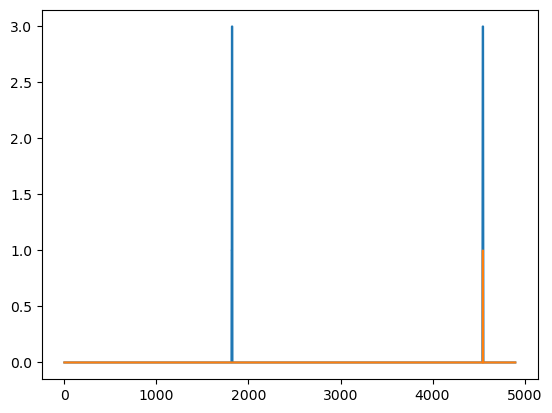

In [16]:
total_lightning_counts.lightning_count_5.plot()
total_lightning_counts.lightning_count_2p5.plot()


In [17]:
type(gdf.geometry[0])

shapely.geometry.point.Point

Find nearest point to cluster centre:

In [18]:
gdf.geometry[0:1]

0    POINT (-59.34153 -19.37459)
Name: geometry, dtype: geometry

In [19]:
nearest_point = gpd.GeoSeries.distance(total_lightning_counts, gdf.geometry[0]).argmin()
nearest_point

/tmp/ipykernel_4455/2032463108.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nearest_point = gpd.GeoSeries.distance(total_lightning_counts, gdf.geometry[0]).argmin()


np.int64(4546)

In [20]:
lightning_patch = total_lightning_counts.iloc[nearest_point-128:nearest_point+127]

In [21]:
lightning_patch

,geometry,lightning_count_2p5,lightning_count_5,time
4418,POINT (-59.10495 -18.19469),0,0,2024-08-07 17:49:29.363952640
4419,POINT (-59.10674 -18.20363),0,0,2024-08-07 17:49:29.502444544
4420,POINT (-59.10852 -18.21257),0,0,2024-08-07 17:49:29.640936576
4421,POINT (-59.11031 -18.22151),0,0,2024-08-07 17:49:29.779428608
4422,POINT (-59.11209 -18.23046),0,0,2024-08-07 17:49:29.917920640
...,...,...,...,...
4668,POINT (-59.56935 -20.49849),0,0,2024-08-07 17:50:05.058395392
4669,POINT (-59.57156 -20.5093),0,0,2024-08-07 17:50:05.226051584
4670,POINT (-59.57338 -20.51826),0,0,2024-08-07 17:50:05.364777600
4671,POINT (-59.57521 -20.5272),0,0,2024-08-07 17:50:05.503503744


<Axes: >

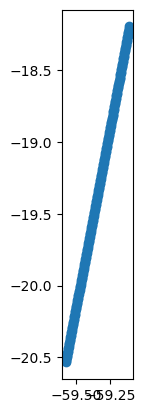

In [22]:
lightning_patch.geometry.plot()

In [23]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)


In [24]:
from scripts.load_earthcare import process_earthcare_patch

In [25]:
process_earthcare_patch(
    lightning_patch, 
    "01101E_LI_0", 
    product_vars = dict(
        ACM_CAP_2B=[
            "ice_water_content", 
            "ice_mass_flux", 
            "ice_effective_radius", 
            "ice_median_volume_diameter", 
            "ice_riming_factor", 
            "rain_rate", 
            "rain_water_content", 
            "rain_median_volume_diameter", 
            "liquid_water_content", 
            "liquid_number_concentration", 
            "liquid_effective_radius", 
            "aerosol_number_concentration", 
            "aerosol_mass_content", 
        ],
        CPR_CD__2A=[
            "doppler_velocity_best_estimate", 
            "sedimentation_velocity_best_estimate", 
            "spectrum_width_integrated", 
        ], 
        CPR_FMR_2A=[
            "reflectivity_no_attenuation_correction", 
            "reflectivity_corrected", 
            "multiple_scattering_status", 
        ], 
        CPR_TC__2A=[
            "simplified_convective_classification",
        ]
    ),
)

In [26]:
xr.open_dataset("earthcare_01101E_LI_0.h5", engine="h5netcdf")

<xarray.Dataset> Size: 4MB
Dimensions:                                 (along_track: 255, height: 200)
Coordinates:
  * along_track                             (along_track) int64 2kB 4418 ... ...
    time                                    (along_track) datetime64[ns] 2kB ...
    latitude                                (along_track) float64 2kB ...
    longitude                               (along_track) float64 2kB ...
  * height                                  (height) float64 2kB 50.0 ... 1.9...
Data variables: (12/22)
    lightning_count_2p5                     (along_track) uint32 1kB ...
    lightning_count_5                       (along_track) uint32 1kB ...
    ice_water_content                       (along_track, height) float32 204kB ...
    ice_mass_flux                           (along_track, height) float32 204kB ...
    ice_effective_radius                    (along_track, height) float32 204kB ...
    ice_median_volume_diameter              (along_track, height) float32 204kB ...
    ...                                      ...
    sedimentation_velocity_best_estimate    (along_track, height) float32 204kB ...
    spectrum_width_integrated               (along_track, height) float32 204kB ...
    reflectivity_no_attenuation_correction  (along_track, height) float32 204kB ...
    reflectivity_corrected                  (along_track, height) float32 204kB ...
    multiple_scattering_status              (along_track, height) float64 408kB ...
    simplified_convective_classification    (along_track, height) float64 408kB ...

In [27]:
patch = xr.open_dataset("earthcare_01101E_LI_0.h5", engine="h5netcdf")

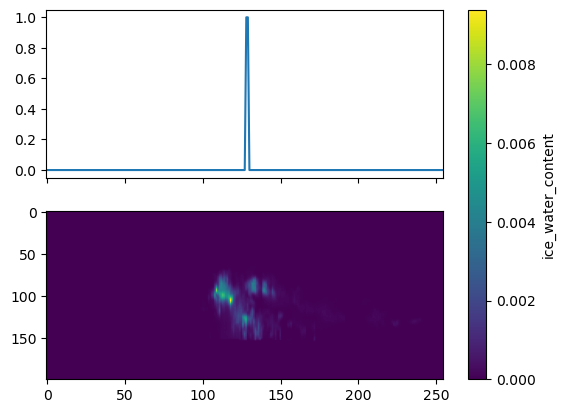

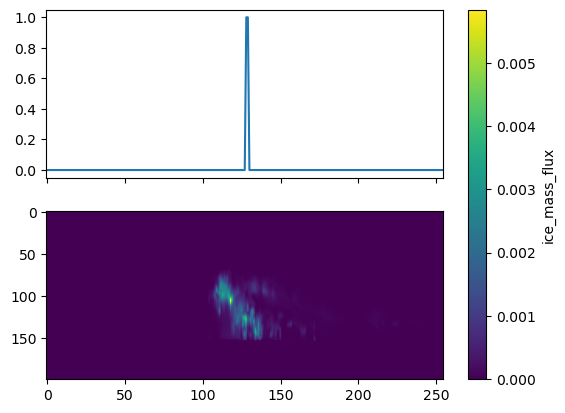

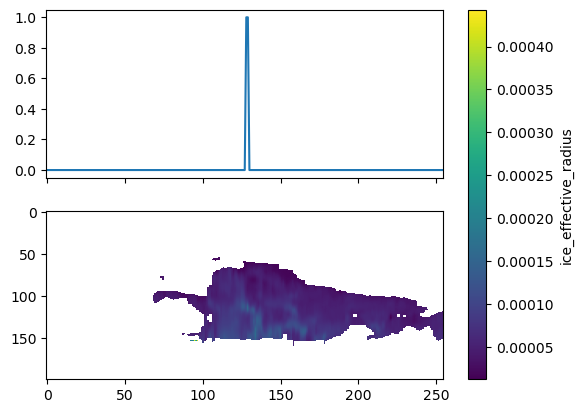

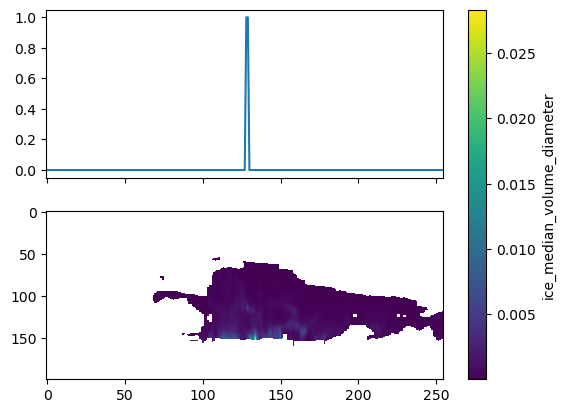

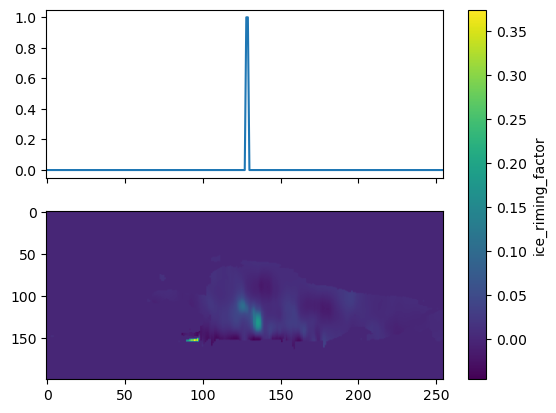

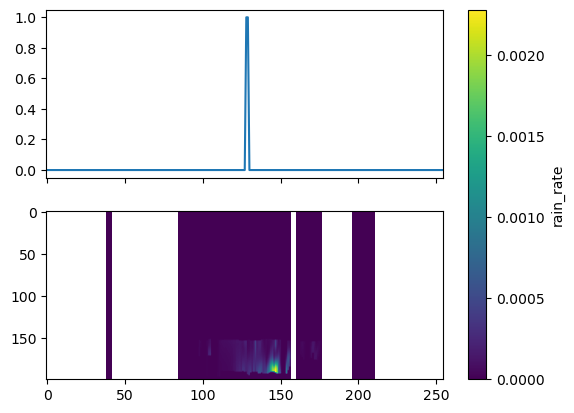

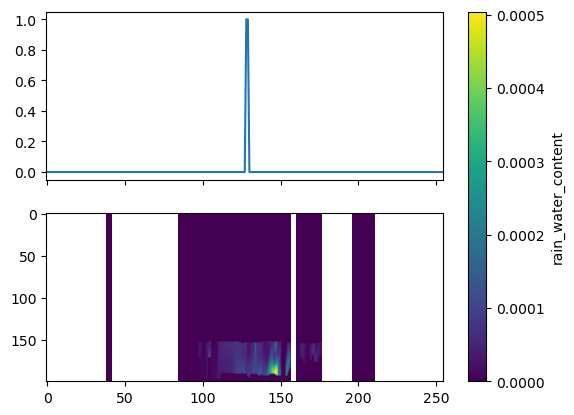

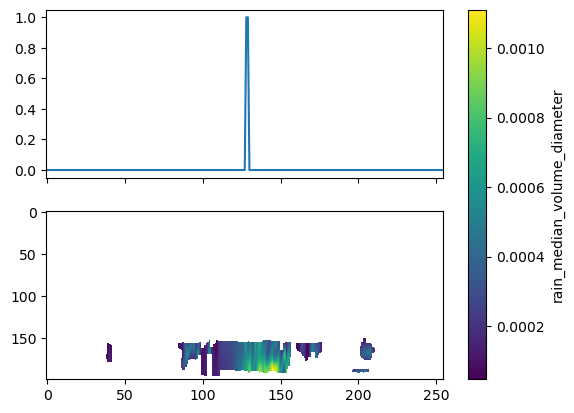

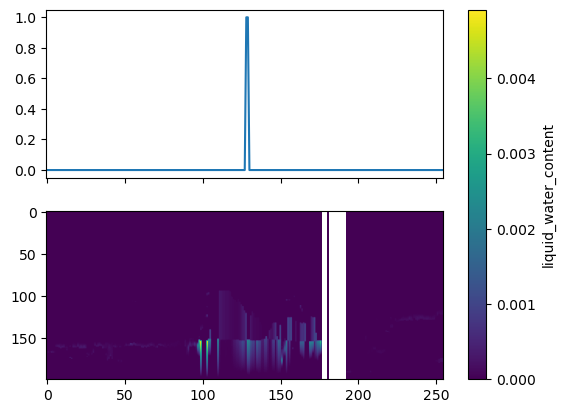

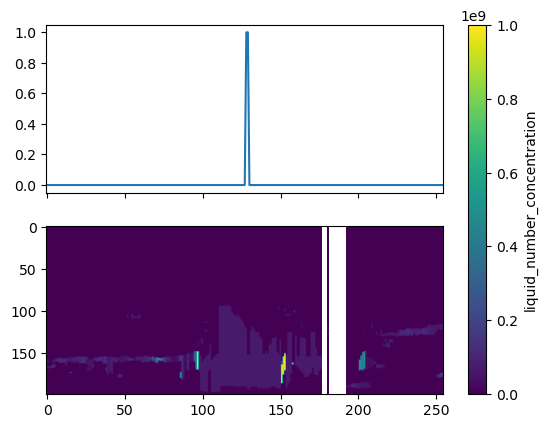

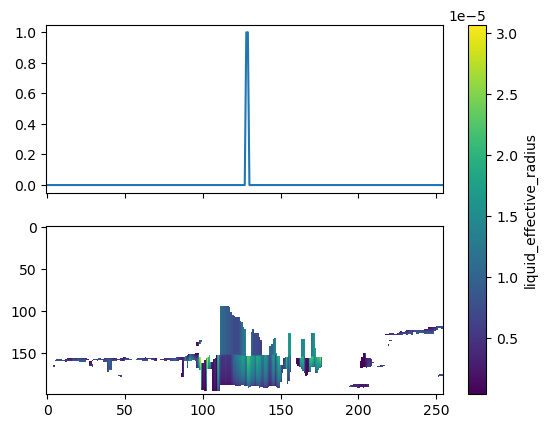

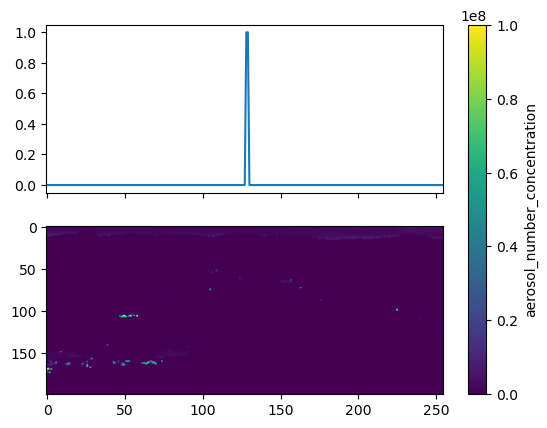

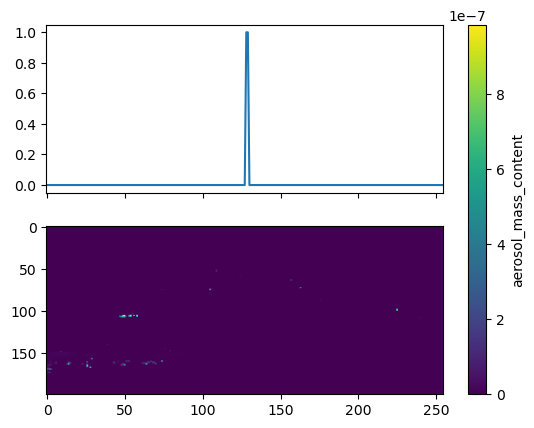

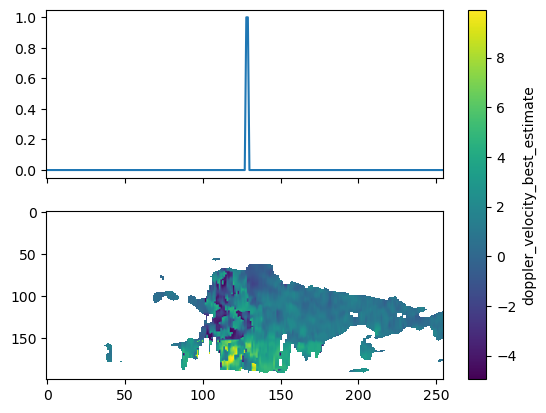

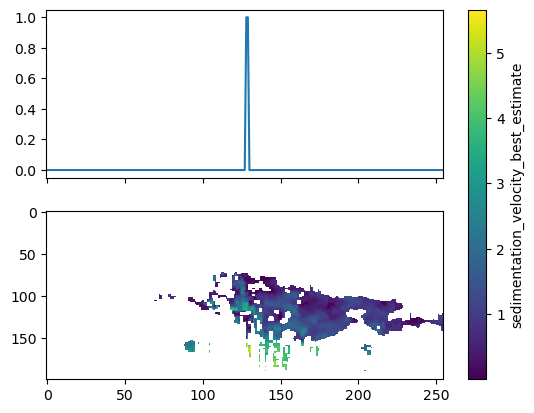

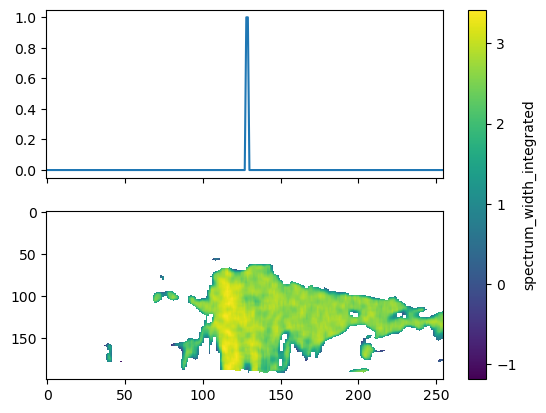

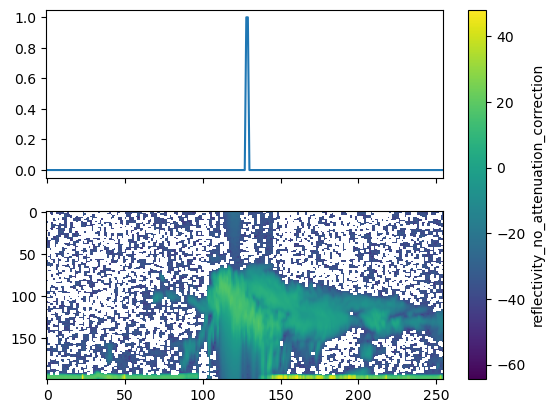

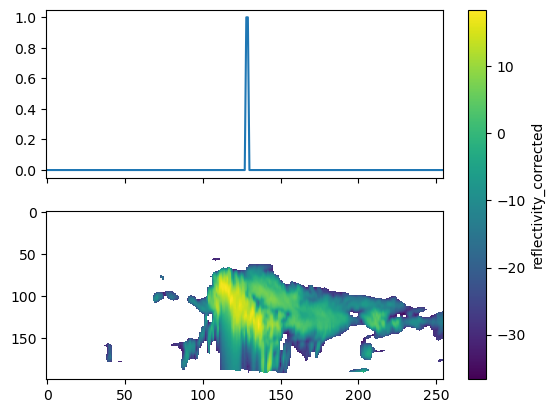

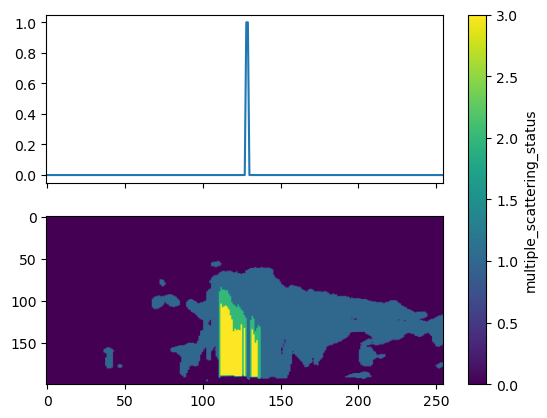

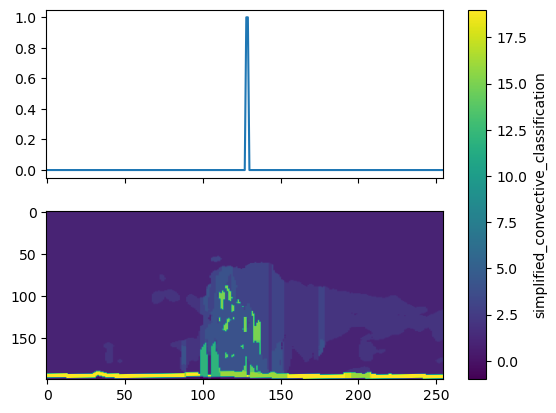

In [28]:
for var in patch.data_vars:
    da = patch[var]
    if da.dims == ("along_track", "height"):
        fig, axes = plt.subplots(2,1,sharex=True)
    
        line = axes[0].plot(lightning_patch.lightning_count_2p5.to_numpy())
        image = axes[1].imshow(da.T, aspect="auto")#, cmap="RdBu_r", vmin=-5, vmax=5)
        
        plt.colorbar(image, ax=axes, orientation="vertical", label=f"{var}")